In [12]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import psycopg2

from sqlalchemy import create_engine
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sqlalchemy import create_engine
from datetime import datetime


DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "epidemic")
DB_USER = os.getenv("DB_USER", "ds551")
DB_PASSWORD = os.getenv("DB_PASSWORD", "ds551pw")

conn_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_url)

engine
conn = psycopg2.connect(
    host="172.30.178.233",
    port=5432,
    dbname="epidemic",
    user="ds551",
    password="ds551pw"
)


In [13]:
pd.read_sql("SELECT 1 as ok;", conn)


/tmp/ipykernel_4006/3344085531.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT 1 as ok;", conn)


,ok
0,1


In [14]:
import os
import uuid
import math
import psycopg2

POSTGRES_HOST = os.getenv("POSTGRES_HOST", "postgres")
POSTGRES_PORT = os.getenv("POSTGRES_PORT", "5432")
POSTGRES_DB = os.getenv("POSTGRES_DB", "epidemic")
POSTGRES_USER = os.getenv("POSTGRES_USER", "ds551")
POSTGRES_PASSWORD = os.getenv("POSTGRES_PASSWORD", "ds551pw")

K = int(os.getenv("ROLLING_K", "3"))  # rolling window size (3 = last 3 points)

def rmse(y_true, y_pred):
    mse = sum((a - b) ** 2 for a, b in zip(y_true, y_pred)) / len(y_true)
    return math.sqrt(mse)

def mae(y_true, y_pred):
    return sum(abs(a - b) for a, b in zip(y_true, y_pred)) / len(y_true)

def main():
    run_id = str(uuid.uuid4())

    conn = psycopg2.connect(
    host="172.30.178.233",
    port=5432,
    dbname="epidemic",
    user="ds551",
    password="ds551pw"
    )

    cur = conn.cursor()

    # Pull time-ordered data (you can also do region-level if you have region/hour table)
    cur.execute("""
        SELECT day_of_week, hour_of_day, event_count
        FROM temporal_patterns
        ORDER BY day_of_week, hour_of_day;
    """)
    rows = cur.fetchall()

    y = [float(r[2]) for r in rows]

    # Build rolling predictions
    y_true, y_pred = [], []
    for i in range(K, len(y)):
        window = y[i-K:i]
        pred = sum(window) / len(window)
        y_true.append(y[i])
        y_pred.append(pred)

    if len(y_true) < 1:
        print("Not enough data points to evaluate rolling average model.")
        return

    r = rmse(y_true, y_pred)
    m = mae(y_true, y_pred)

    # Store results
    cur.execute("""
        INSERT INTO model_comparison(run_id, model_name, rmse, mae)
        VALUES (%s, %s, %s, %s);
    """, (run_id, f"rolling_avg_k={K}", r, m))

    conn.commit()
    cur.close()
    conn.close()

    print(f"[OK] Stored Model B rolling average results. run_id={run_id} rmse={r:.4f} mae={m:.4f}")

if __name__ == "__main__":
    main()


[OK] Stored Model B rolling average results. run_id=590e743d-709e-4cae-8cca-769df12ffc32 rmse=26171.8306 mae=6801.4222


In [15]:
df = pd.read_sql("""
SELECT day_of_week, hour_of_day, event_count
FROM temporal_patterns
ORDER BY day_of_week, hour_of_day;
""", conn)

df.head()


/tmp/ipykernel_4006/2186006682.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,day_of_week,hour_of_day,event_count
0,1.0,5.0,209
1,1.0,6.0,583
2,1.0,7.0,601
3,1.0,8.0,596
4,1.0,9.0,570


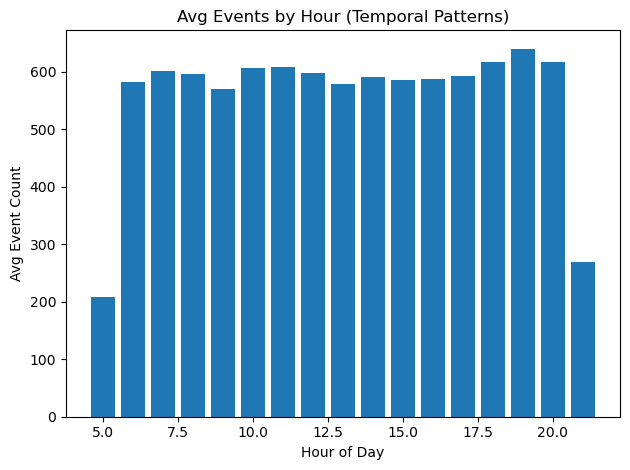

In [16]:
import matplotlib.pyplot as plt

hourly = df.groupby("hour_of_day")["event_count"].mean().reset_index()

plt.figure()
plt.bar(hourly["hour_of_day"], hourly["event_count"])
plt.xlabel("Hour of Day")
plt.ylabel("Avg Event Count")
plt.title("Avg Events by Hour (Temporal Patterns)")
plt.tight_layout()

# Save so TA can see
plt.savefig("avg_events_by_hour.png", dpi=200)
plt.show()


In [17]:
import numpy as np
import math

y = df["event_count"].astype(float).to_numpy()
K = 3

y_true, y_pred = [], []
for i in range(K, len(y)):
    y_true.append(y[i])
    y_pred.append(np.mean(y[i-K:i]))

rmse = math.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))
mae = np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

rmse, mae


(26171.830629585384, 6801.4222222222215)

In [18]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sqlalchemy import create_engine
from datetime import datetime


In [19]:
DB_USER = "ds551"
DB_PASSWORD = "ds551pw"
DB_HOST = "postgres"
DB_PORT = 5432
DB_NAME = "epidemic"

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)


In [20]:
query = """
SELECT day_of_week, hour_of_day, event_count
FROM temporal_patterns
ORDER BY day_of_week, hour_of_day
"""
df = pd.read_sql(query, engine)
df.head()


,day_of_week,hour_of_day,event_count
0,1.0,5.0,209
1,1.0,6.0,583
2,1.0,7.0,601
3,1.0,8.0,596
4,1.0,9.0,570


In [21]:
df = df.dropna(subset=[
    "day_of_week",
    "hour_of_day",
    "event_count"
])

X = df[["day_of_week", "hour_of_day"]]
y = df["event_count"]



In [22]:
df["rolling_pred"] = (
    df["event_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)

rmse_a = mean_squared_error(y, df["rolling_pred"], squared=False)
mae_a = mean_absolute_error(y, df["rolling_pred"])

rmse_a, mae_a


(92.86826225351118, 51.95392156862745)

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
model = LinearRegression()
model.fit(X_train, y_train)
lr_pred = model.predict(X_test)

#df["lr_pred"] = model.predict(X_test)
rmse_b=mean_squared_error(y_test, lr_pred, squared=False)
mae_b=mean_absolute_error(y_test, lr_pred)
rmse_b,mae_b

#rmse_b = mean_squared_error(y, df["lr_pred"], squared=False)
#mae_b = mean_absolute_error(y, df["lr_pred"])


(227.51819358602344, 149.37508445945946)

In [28]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

gbr=GradientBoostingRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
)

gbr.fit(X_train, y_train)
gbr_pred=gbr.predict(X_test)

gbr_rmse=mean_squared_error(y_test, gbr_pred) ** 0.5
gbr_mae=mean_absolute_error(y_test, gbr_pred)
gbr_rmse, gbr_mae


(199.1498175207383, 126.02216519412949)

In [29]:
comparison = pd.DataFrame({
    "model": ["Rolling Average", "Linear Regression","Gradient Boosting"],
    "RMSE": [rmse_a, rmse_b,gbr_rmse],
    "MAE": [mae_a, mae_b,gbr_mae]
})

comparison


,model,RMSE,MAE
0,Rolling Average,92.868262,51.953922
1,Linear Regression,227.518194,149.375084
2,Gradient Boosting,199.149818,126.022165


In [30]:
run_id = f"run_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"

results = pd.DataFrame([
    {"run_id": run_id, "model_name": "Rolling Average", "rmse": rmse_a, "mae": mae_a},
    {"run_id": run_id, "model_name": "Linear Regression", "rmse": rmse_b, "mae": mae_b},
    {"run_id": run_id,"model_name": "Gradient Boosting","rmse": gbr_rmse,"mae": gbr_mae},
])

results.to_sql(
    "model_comparison",
    engine,
    if_exists="append",
    index=False
)

results


,run_id,model_name,rmse,mae
0,run_20251215_013216,Rolling Average,92.868262,51.953922
1,run_20251215_013216,Linear Regression,227.518194,149.375084
2,run_20251215_013216,Gradient Boosting,199.149818,126.022165


<Axes: title={'center': 'Model Performance Comparison'}, xlabel='model'>

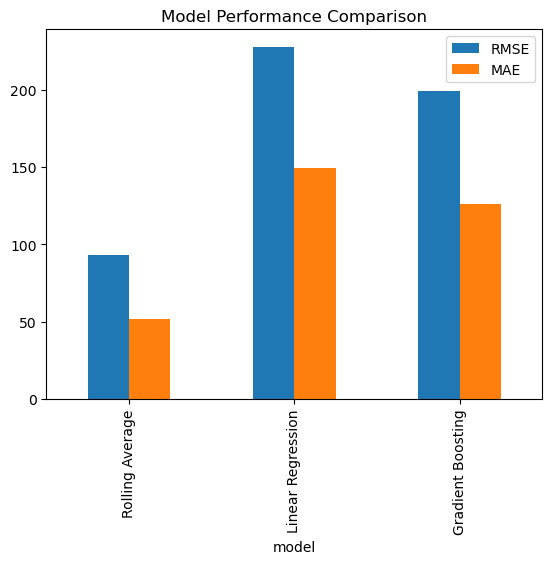

In [31]:
comparison.plot(
    x="model",
    y=["RMSE", "MAE"],
    kind="bar",
    title="Model Performance Comparison"
)
